# Naive baseline

For this, we assume we have access to training data sampled sparsely from the underling conditional temporal process (x, y, t). 

We then want to train a NN $\Phi(x, t) = y$, in a supervised manner. Then, we can sample from this naive surrogate at arbitrary t, with condition x, to get arbitrary temporal distribution

In [3]:
import time
import torch
from torch import nn, Tensor
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
from sklearn.datasets import make_moons
import numpy as np
from scipy.stats import vonmises as scipy_vonmises
from scipy.stats import lognorm as scipy_lognorm
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [5]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using gpu


In [6]:
torch.manual_seed(42)

In [7]:
def semicircle_data():
    """
    Loads the semicircle dataset.
    """

    data = torch.load("../NLOT/data/conditional_semicircles.pt")
    data = data.to(device)
    return data

In [8]:
semicircle_data = semicircle_data()

In [22]:
#concat 0 to each entry in semicircle_data[0,:,:]

semicircle_data_time_0 = torch.cat((semicircle_data[0,:,:], torch.zeros(semicircle_data[0,:,:].shape[0], 1, device=device)), dim=1)
semicircle_data_time_05 = torch.cat((semicircle_data[1,:,:], torch.ones(semicircle_data[1,:,:].shape[0], 1, device=device) * 0.5), dim=1)
semicircle_data_time_1 = torch.cat((semicircle_data[2,:,:], torch.ones(semicircle_data[2,:,:].shape[0], 1, device=device)), dim=1)

flattened_semicircle_data = torch.cat((semicircle_data_time_0, semicircle_data_time_05, semicircle_data_time_1), dim=0)

In [27]:
output = flattened_semicircle_data[:, :2]
input = flattened_semicircle_data[:, 2:]

In [28]:
output

tensor([[-0.1920,  0.5221],
        [-0.0387,  0.1457],
        [-0.2248,  0.4138],
        ...,
        [ 1.8934,  0.1850],
        [ 2.0822,  0.1160],
        [ 1.8804,  0.2457]], device='cuda:0')

In [29]:
input

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        ...,
        [3., 1.],
        [3., 1.],
        [3., 1.]], device='cuda:0')

# Naive RL

In [19]:
def rl_data_gen():
    """
    Loads the rl reward weighting dataset.
    """

    data = torch.load("../NLOT/data/reward_weighting_data_0_10.pt")
    data = data.to(device)
    return data

In [20]:
rl_data = rl_data_gen()
rl_data = rl_data[:,:1000]
rl_training_data = rl_data[[0,5,10]]

In [21]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [23]:
print("RL training data shape:", rl_training_data.shape)
print("Shape of each timepoint:", rl_training_data[0].shape)
print("Total features per sample:", rl_training_data[0].shape[1])

RL training data shape: torch.Size([3, 1000, 9])
Shape of each timepoint: torch.Size([1000, 9])
Total features per sample: 9


In [24]:
# Prepare RL training data
def prepare_rl_training_data():
    """
    Prepare RL data for training according to requirements:
    - Input 'x': first 2 entries from timepoint 0
    - Input 't': desired timepoint (0, 5, or 10) 
    - Input 'cond': remaining 7 entries from timepoint 0
    - Target: first 2 entries from the corresponding row at target timepoint
    """
    
    # rl_training_data shape: [3, 1000, 9] - timepoints [0,5,10], 1000 samples, 9 features
    timepoint_0_data = rl_training_data[0]  # [1000, 9]
    timepoint_5_data = rl_training_data[1]  # [1000, 9] 
    timepoint_10_data = rl_training_data[2]  # [1000, 9]
    
    # Extract components from timepoint 0
    x_base = timepoint_0_data[:, :2]  # First 2 entries [1000, 2]
    cond_base = timepoint_0_data[:, 2:]  # Remaining 7 entries [1000, 7]
    
    # Create training samples for each target timepoint
    all_x = []
    all_t = []
    all_cond = []
    all_targets = []
    
    # Target timepoint 0 (identity mapping)
    all_x.append(x_base)
    all_t.append(torch.zeros(1000, 1, device=device))  # t=0
    all_cond.append(cond_base)
    all_targets.append(timepoint_0_data[:, :2])  # First 2 entries of timepoint 0
    
    # Target timepoint 5
    all_x.append(x_base)
    all_t.append(torch.full((1000, 1), 5.0, device=device))  # t=5
    all_cond.append(cond_base)
    all_targets.append(timepoint_5_data[:, :2])  # First 2 entries of timepoint 5
    
    # Target timepoint 10
    all_x.append(x_base)
    all_t.append(torch.full((1000, 1), 10.0, device=device))  # t=10
    all_cond.append(cond_base)
    all_targets.append(timepoint_10_data[:, :2])  # First 2 entries of timepoint 10
    
    # Concatenate all training data
    train_x = torch.cat(all_x, dim=0)  # [3000, 2]
    train_t = torch.cat(all_t, dim=0)  # [3000, 1]
    train_cond = torch.cat(all_cond, dim=0)  # [3000, 7]
    train_targets = torch.cat(all_targets, dim=0)  # [3000, 2]
    
    return {
        'x': train_x,
        't': train_t, 
        'cond': train_cond,
        'targets': train_targets
    }

# Prepare the training data
rl_train_data = prepare_rl_training_data()
print(f"Training data shapes:")
print(f"x: {rl_train_data['x'].shape}")
print(f"t: {rl_train_data['t'].shape}")
print(f"cond: {rl_train_data['cond'].shape}")
print(f"targets: {rl_train_data['targets'].shape}")

Training data shapes:
x: torch.Size([3000, 2])
t: torch.Size([3000, 1])
cond: torch.Size([3000, 7])
targets: torch.Size([3000, 2])


In [33]:
# Training function for RL model
def train_rl_model(model, train_data, num_epochs=1000, learning_rate=1e-3, batch_size=256):
    """
    Train the RL neural network model.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    x_data = train_data['x']
    t_data = train_data['t']
    cond_data = train_data['cond']
    target_data = train_data['targets']
    
    num_samples = x_data.shape[0]
    losses = []
    
    print(f"Training for {num_epochs} epochs with batch size {batch_size}")
    print(f"Dataset size: {num_samples} samples")
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        num_batches = 0
        
        # Shuffle data
        perm = torch.randperm(num_samples)
        x_shuffled = x_data[perm]
        t_shuffled = t_data[perm]
        cond_shuffled = cond_data[perm]
        target_shuffled = target_data[perm]
        
        # Mini-batch training
        for i in range(0, num_samples, batch_size):
            batch_x = x_shuffled[i:i+batch_size]
            batch_t = t_shuffled[i:i+batch_size]
            batch_cond = cond_shuffled[i:i+batch_size]
            batch_targets = target_shuffled[i:i+batch_size]
            
            optimizer.zero_grad()
            
            # Forward pass
            predictions = model(batch_x, batch_t, batch_cond)
            loss = criterion(predictions, batch_targets)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.6f}")
    
    return losses

In [34]:
# Initialize and train the RL model
rl_model = MLP(
    input_dim=2,     # First 2 entries from timepoint 0
    time_dim=1,      # Timepoint (0, 5, or 10)
    hidden_dim=128,  # Hidden layer size
    cond_dim=7       # Remaining 7 entries from timepoint 0
).to(device)

print("Starting RL model training...")
rl_losses = train_rl_model(
    model=rl_model,
    train_data=rl_train_data,
    num_epochs=10000,
    learning_rate=1e-3,
    batch_size=256
)

Starting RL model training...
Training for 10000 epochs with batch size 256
Dataset size: 3000 samples


Epoch [100/10000], Average Loss: 0.197984
Epoch [200/10000], Average Loss: 0.195830
Epoch [300/10000], Average Loss: 0.182771
Epoch [400/10000], Average Loss: 0.187220
Epoch [500/10000], Average Loss: 0.179864
Epoch [600/10000], Average Loss: 0.177683
Epoch [700/10000], Average Loss: 0.180849
Epoch [800/10000], Average Loss: 0.170043
Epoch [900/10000], Average Loss: 0.161998
Epoch [1000/10000], Average Loss: 0.145067
Epoch [1100/10000], Average Loss: 0.124207
Epoch [1200/10000], Average Loss: 0.109964
Epoch [1300/10000], Average Loss: 0.089758
Epoch [1400/10000], Average Loss: 0.075223
Epoch [1500/10000], Average Loss: 0.059985
Epoch [1600/10000], Average Loss: 0.052840
Epoch [1700/10000], Average Loss: 0.039303
Epoch [1800/10000], Average Loss: 0.033226
Epoch [1900/10000], Average Loss: 0.028283
Epoch [2000/10000], Average Loss: 0.032041
Epoch [2100/10000], Average Loss: 0.022889
Epoch [2200/10000], Average Loss: 0.023111
Epoch [2300/10000], Average Loss: 0.021767
Epoch [2400/10000], 

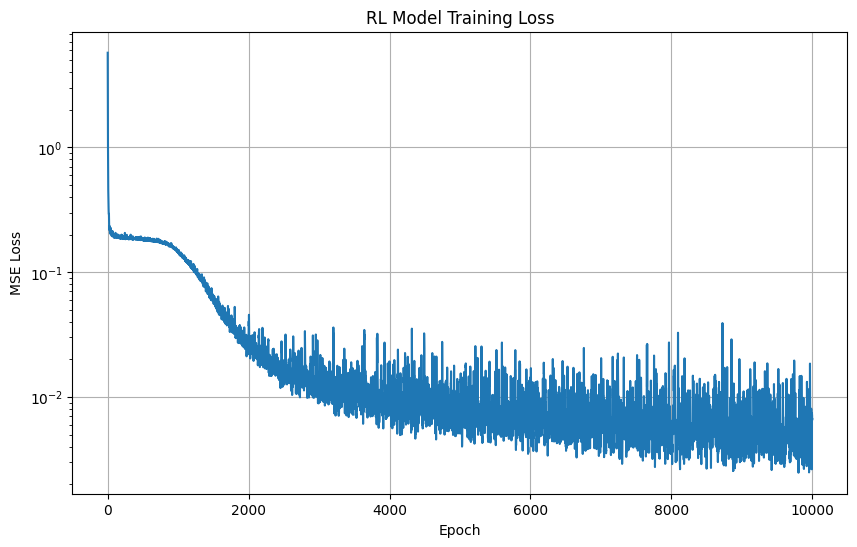

Final training loss: 0.006672


In [35]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(rl_losses)
plt.title('RL Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

print(f"Final training loss: {rl_losses[-1]:.6f}")

In [36]:
# Test the trained model
def test_rl_model(model, test_indices=[0, 1, 2], target_timepoints=[0, 5, 10]):
    """
    Test the trained model on specific samples
    """
    model.eval()
    
    with torch.no_grad():
        # Get test data from timepoint 0
        test_x = rl_training_data[0][test_indices, :2]  # First 2 entries
        test_cond = rl_training_data[0][test_indices, 2:]  # Remaining 7 entries
        
        print("Testing model predictions:")
        print("=" * 50)
        
        for i, idx in enumerate(test_indices):
            print(f"\nSample {idx}:")
            print(f"Input x (from t=0): {test_x[i].cpu().numpy()}")
            print(f"Conditioning: {test_cond[i].cpu().numpy()}")
            
            for target_t in target_timepoints:
                # Predict
                t_tensor = torch.tensor([[float(target_t)]], device=device)
                x_input = test_x[i:i+1]
                cond_input = test_cond[i:i+1]
                
                prediction = model(x_input, t_tensor, cond_input)
                
                # Get ground truth
                timepoint_idx = {0: 0, 5: 1, 10: 2}[target_t]
                ground_truth = rl_training_data[timepoint_idx][idx, :2]
                
                pred_np = prediction[0].cpu().numpy()
                gt_np = ground_truth.cpu().numpy()
                error = torch.norm(prediction[0] - ground_truth).item()
                
                print(f"  t={target_t}: Predicted=[{pred_np[0]:.4f}, {pred_np[1]:.4f}], "
                      f"Ground Truth=[{gt_np[0]:.4f}, {gt_np[1]:.4f}], "
                      f"Error={error:.4f}")

# Test the model
test_rl_model(rl_model)

Testing model predictions:

Sample 0:
Input x (from t=0): [0.        2.9635572]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[-0.0045, 2.9666], Ground Truth=[0.0000, 2.9636], Error=0.0055
  t=5: Predicted=[5.8235, 1.1908], Ground Truth=[5.8026, 1.1765], Error=0.0253
  t=10: Predicted=[9.6875, 2.9248], Ground Truth=[9.7287, 3.0308], Error=0.1138

Sample 1:
Input x (from t=0): [0.        2.0878088]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[0.0040, 2.0720], Ground Truth=[0.0000, 2.0878], Error=0.0163
  t=5: Predicted=[6.1608, 0.2186], Ground Truth=[6.2944, 0.4304], Error=0.2504
  t=10: Predicted=[9.9380, 2.0080], Ground Truth=[10.0000, 1.9903], Error=0.0645

Sample 2:
Input x (from t=0): [0.        1.9325614]
Conditioning: [16.257835  19.044903   4.419331  21.099571   0.         8.934413
  4.8995204]
  t=0: Predicted=[-0.0143, 1.9038], Ground Truth=[0.0000,

In [37]:
# Comprehensive evaluation
def evaluate_model_performance(model):
    """
    Evaluate model performance on all data
    """
    model.eval()
    
    with torch.no_grad():
        # Test on all timepoints
        x_input = rl_train_data['x']
        t_input = rl_train_data['t']
        cond_input = rl_train_data['cond']
        targets = rl_train_data['targets']
        
        # Get predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Calculate MSE for each timepoint
        mse_per_timepoint = {}
        for t_val in [0, 5, 10]:
            mask = (t_input.squeeze() == t_val)
            if mask.sum() > 0:
                pred_t = predictions[mask]
                target_t = targets[mask]
                mse_t = torch.mean((pred_t - target_t) ** 2).item()
                mse_per_timepoint[t_val] = mse_t
                print(f"MSE for timepoint {t_val}: {mse_t:.6f}")
        
        # Overall MSE
        overall_mse = torch.mean((predictions - targets) ** 2).item()
        print(f"Overall MSE: {overall_mse:.6f}")
        
        return mse_per_timepoint, overall_mse

# Evaluate the model
print("Model Performance Evaluation:")
print("=" * 40)
timepoint_mse, overall_mse = evaluate_model_performance(rl_model)

Model Performance Evaluation:
MSE for timepoint 0: 0.000794
MSE for timepoint 5: 0.011228
MSE for timepoint 10: 0.008454
Overall MSE: 0.006825


In [40]:
# Plotting function for model outputs
def plot_model_outputs_at_timepoint(model, target_timepoint, num_samples=None, figsize=(12, 8)):
    """
    Plot the outputs of the trained NN casting all entries at timepoint 0 to an arbitrary target timepoint
    
    Args:
        model: Trained MLP model
        target_timepoint: Target timepoint to cast to (can be any float value)
        num_samples: Number of samples to plot (None for all 1000 samples)
        figsize: Figure size for the plot
    """
    model.eval()
    
    if num_samples is None:
        num_samples = rl_training_data[0].shape[0]  # Use all samples
    else:
        num_samples = min(num_samples, rl_training_data[0].shape[0])
    
    with torch.no_grad():
        # Get input data from timepoint 0
        x_input = rl_training_data[0][:num_samples, :2]  # First 2 entries [N, 2]
        cond_input = rl_training_data[0][:num_samples, 2:]  # Remaining 7 entries [N, 7]
        
        # Create time tensor for target timepoint
        t_input = torch.full((num_samples, 1), float(target_timepoint), device=device)
        
        # Get model predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Convert to numpy for plotting
        predictions_np = predictions.cpu().numpy()
        
        # Create single plot of predicted distribution
        plt.figure(figsize=(8, 6))
        plt.scatter(predictions_np[:, 0], predictions_np[:, 1], alpha=0.6, s=20, c='red')
        plt.xlabel('Predicted x[0]')
        plt.ylabel('Predicted x[1]')
        plt.title(f'Predicted Distribution at t={target_timepoint}')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Print some statistics
        print(f"Statistics for {num_samples} samples at t={target_timepoint}:")
        print(f"Predicted range - x[0]: [{predictions_np[:, 0].min():.3f}, {predictions_np[:, 0].max():.3f}], "
              f"x[1]: [{predictions_np[:, 1].min():.3f}, {predictions_np[:, 1].max():.3f}]")
        
        return predictions_np

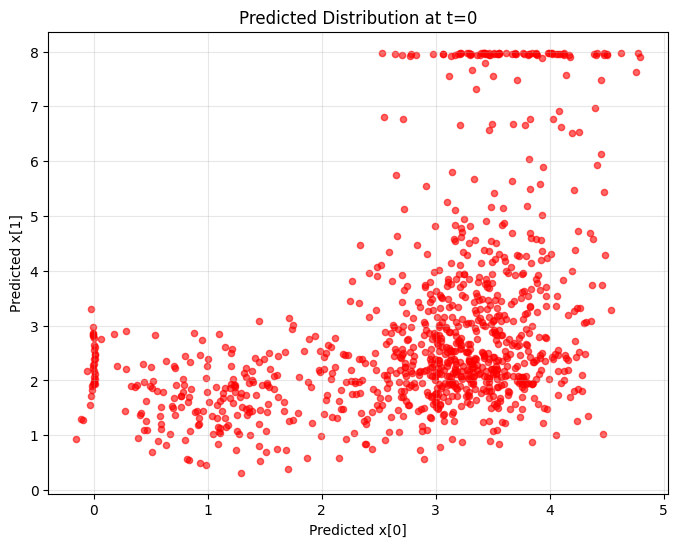

Statistics for 1000 samples at t=0:
Predicted range - x[0]: [-0.153, 4.791], x[1]: [0.317, 7.978]


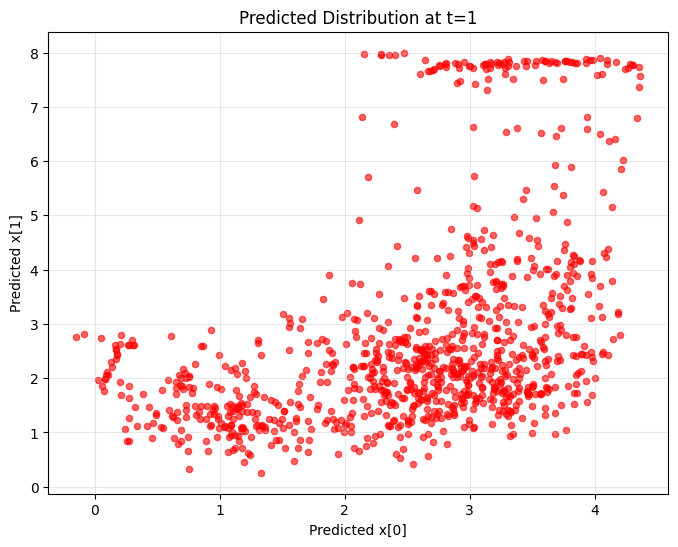

Statistics for 1000 samples at t=1:
Predicted range - x[0]: [-0.146, 4.362], x[1]: [0.257, 7.996]


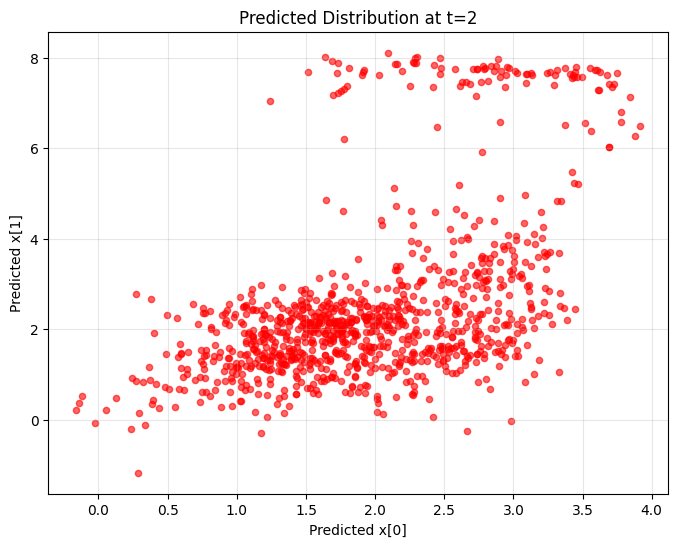

Statistics for 1000 samples at t=2:
Predicted range - x[0]: [-0.160, 3.915], x[1]: [-1.174, 8.116]


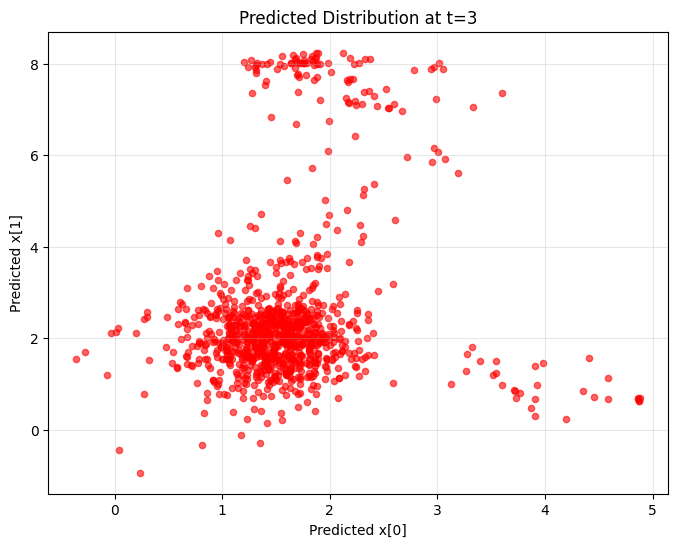

Statistics for 1000 samples at t=3:
Predicted range - x[0]: [-0.357, 4.883], x[1]: [-0.933, 8.237]


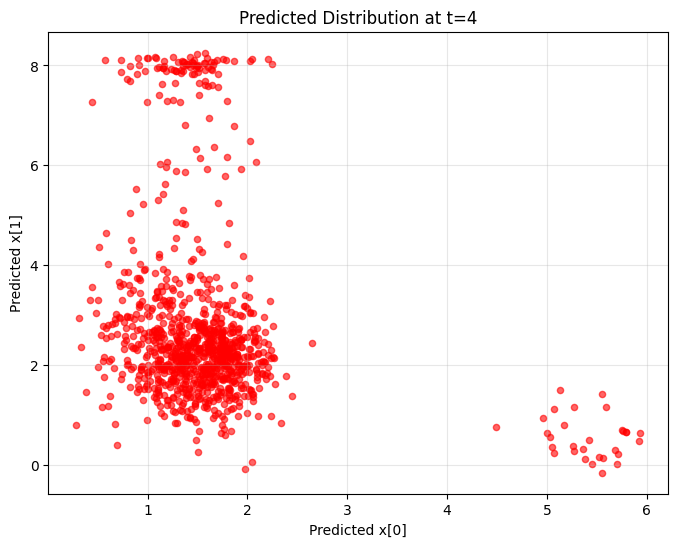

Statistics for 1000 samples at t=4:
Predicted range - x[0]: [0.285, 5.933], x[1]: [-0.152, 8.255]


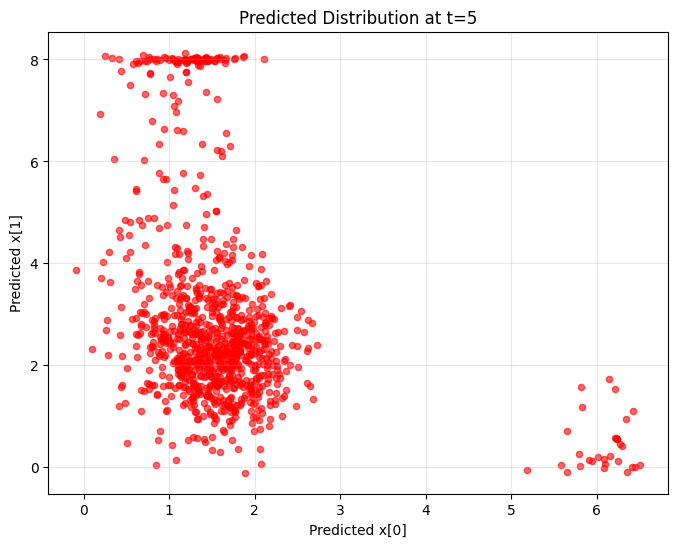

Statistics for 1000 samples at t=5:
Predicted range - x[0]: [-0.087, 6.507], x[1]: [-0.106, 8.131]


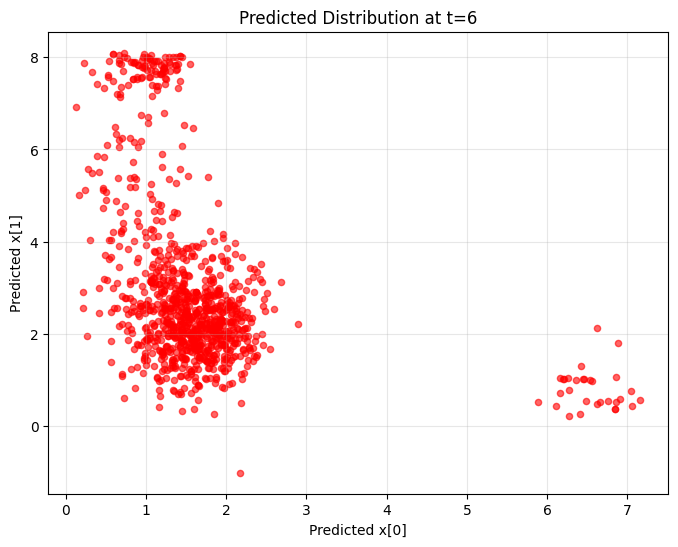

Statistics for 1000 samples at t=6:
Predicted range - x[0]: [0.132, 7.158], x[1]: [-1.018, 8.100]


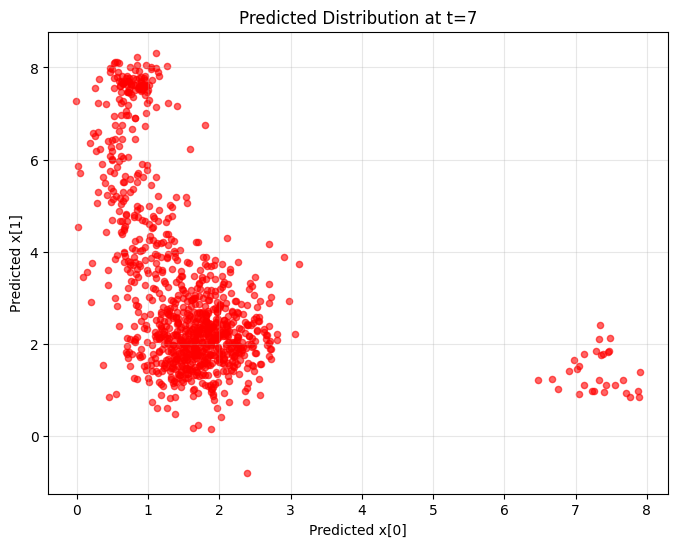

Statistics for 1000 samples at t=7:
Predicted range - x[0]: [-0.007, 7.905], x[1]: [-0.802, 8.320]


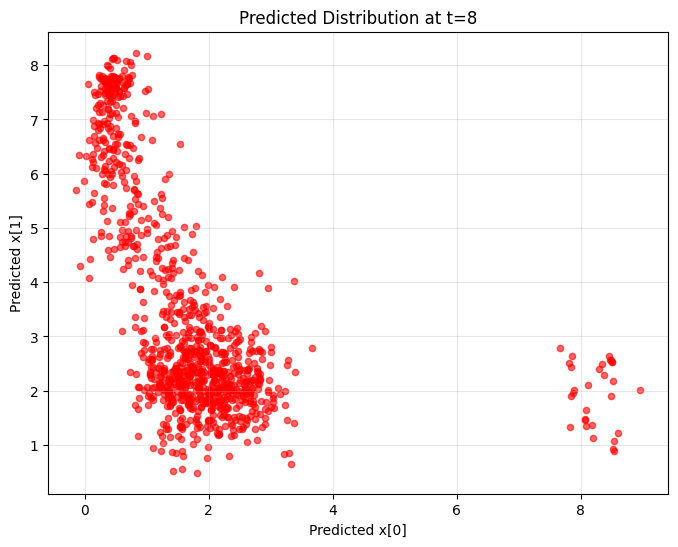

Statistics for 1000 samples at t=8:
Predicted range - x[0]: [-0.135, 8.954], x[1]: [0.487, 8.231]


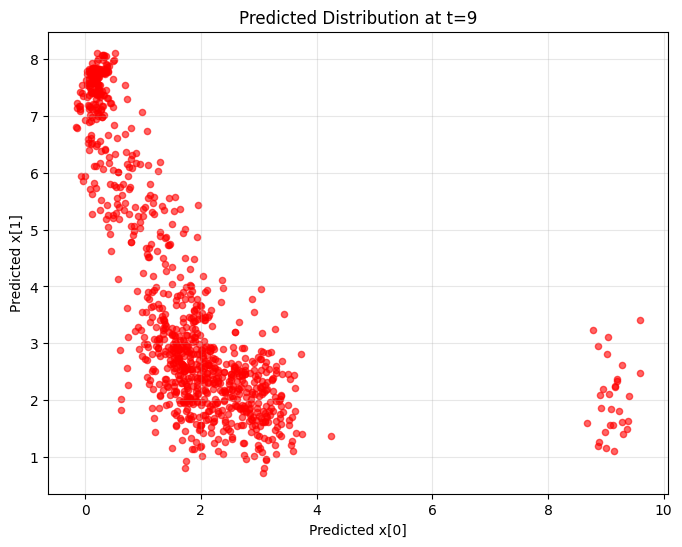

Statistics for 1000 samples at t=9:
Predicted range - x[0]: [-0.152, 9.590], x[1]: [0.727, 8.107]


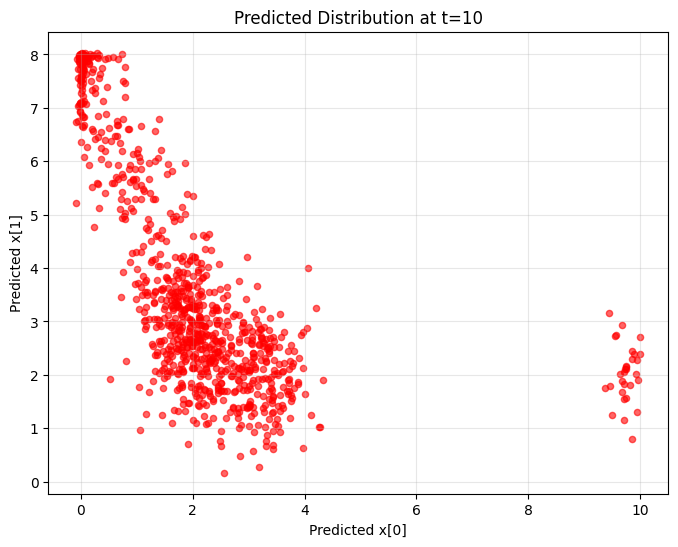

Statistics for 1000 samples at t=10:
Predicted range - x[0]: [-0.083, 10.001], x[1]: [0.168, 8.032]


array([[9.687484 , 2.9247708],
       [9.93803  , 2.007981 ],
       [9.501758 , 1.2402387],
       ...,
       [1.8115029, 2.6105711],
       [1.7281458, 3.304793 ],
       [2.524201 , 2.4779773]], dtype=float32)

In [42]:
plot_model_outputs_at_timepoint(rl_model, target_timepoint=0, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=1, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=2, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=3, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=4, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=5, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=6, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=7, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=8, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=9, num_samples=1000)
plot_model_outputs_at_timepoint(rl_model, target_timepoint=10, num_samples=1000)

In [ ]:
# Comparison function: Model predictions vs Ground Truth
def compare_predictions_vs_ground_truth(model, target_timepoint, num_samples=500):
    """
    Compare model predictions with ground truth at training timepoints
    """
    # Map timepoint to index
    timepoint_to_idx = {0: 0, 5: 1, 10: 2}
    
    if target_timepoint not in timepoint_to_idx:
        print(f"Ground truth not available for timepoint {target_timepoint}")
        return
        
    model.eval()
    idx = timepoint_to_idx[target_timepoint]
    
    with torch.no_grad():
        # Get input data from timepoint 0
        x_input = rl_training_data[0][:num_samples, :2]
        cond_input = rl_training_data[0][:num_samples, 2:]
        t_input = torch.full((num_samples, 1), float(target_timepoint), device=device)
        
        # Get model predictions
        predictions = model(x_input, t_input, cond_input)
        
        # Get ground truth
        ground_truth = rl_training_data[idx][:num_samples, :2]
        
        # Convert to numpy
        predictions_np = predictions.cpu().numpy()
        ground_truth_np = ground_truth.cpu().numpy()
        
        # Create comparison plot
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Plot 1: Prediction vs Ground Truth scatter for first dimension
        axes[0].scatter(ground_truth_np[:, 0], predictions_np[:, 0], alpha=0.6, s=20)
        axes[0].plot([ground_truth_np[:, 0].min(), ground_truth_np[:, 0].max()], 
                     [ground_truth_np[:, 0].min(), ground_truth_np[:, 0].max()], 'r--', alpha=0.8)
        axes[0].set_xlabel('Ground Truth x[0]')
        axes[0].set_ylabel('Predicted x[0]')
        axes[0].set_title(f'First Dimension at t={target_timepoint}\n(Red line = perfect prediction)')
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Prediction vs Ground Truth scatter for second dimension
        axes[1].scatter(ground_truth_np[:, 1], predictions_np[:, 1], alpha=0.6, s=20)
        axes[1].plot([ground_truth_np[:, 1].min(), ground_truth_np[:, 1].max()], 
                     [ground_truth_np[:, 1].min(), ground_truth_np[:, 1].max()], 'r--', alpha=0.8)
        axes[1].set_xlabel('Ground Truth x[1]')
        axes[1].set_ylabel('Predicted x[1]')
        axes[1].set_title(f'Second Dimension at t={target_timepoint}\n(Red line = perfect prediction)')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: 2D comparison
        axes[2].scatter(ground_truth_np[:, 0], ground_truth_np[:, 1], alpha=0.6, s=20, 
                       c='blue', label='Ground Truth')
        axes[2].scatter(predictions_np[:, 0], predictions_np[:, 1], alpha=0.6, s=20, 
                       c='red', label='Predictions')
        axes[2].set_xlabel('x[0]')
        axes[2].set_ylabel('x[1]')
        axes[2].set_title(f'2D Distribution Comparison at t={target_timepoint}')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate and print error metrics
        mse = ((predictions_np - ground_truth_np) ** 2).mean()
        mae = np.abs(predictions_np - ground_truth_np).mean()
        
        print(f"Error metrics for t={target_timepoint}:")
        print(f"MSE: {mse:.6f}")
        print(f"MAE: {mae:.6f}")
        
        return predictions_np, ground_truth_np

# Example comparison at training timepoints
print("Comparing predictions vs ground truth:")
print("=" * 50)

pred_0, gt_0 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=0, num_samples=500)
pred_5, gt_5 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=5, num_samples=500)
pred_10, gt_10 = compare_predictions_vs_ground_truth(rl_model, target_timepoint=10, num_samples=500)